## Image Understanding with RAG using OpenAI's Vision & Responses APIs
Welcome! This notebook demonstrates how to build a Retrieval-Augmented Generation (RAG) system using OpenAI’s Vision and Responses APIs. It focuses on multimodal data, combining image and text inputs to analyze customer experiences. The system leverages GPT-5 and integrates image understanding with file search to provide context-aware responses.

Multimodal datasets are increasingly common, particularly in domains like healthcare, where records often contain both visual data (e.g. radiology scans) and accompanying text (e.g. clinical notes). Real-world datasets also tend to be noisy, with incomplete or missing information, making it critical to analyze multiple modalities in tandem.

This guide focuses on a customer service use case: evaluating customer feedback that may include photos, and written reviews. You’ll learn how to synthetically generate both image and text inputs, use file search for context retrieval, and apply the Evals API to assess how incorporating image understanding impacts overall performance.

In [2]:
pip install openai evals pandas numpy matplotlib tqdm ipython --upgrade

  Obtaining dependency information for openai from https://files.pythonhosted.org/packages/78/0f/cc6afea3542a5142c5d8fc8211c5e059a8375105d004a41dfa2c7948dbb0/openai-2.53.0-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.6 MB/s eta 0:00:00
  Obtaining dependency information for evals from https://files.pythonhosted.org/packages/7f/e4/b54a8285cd6bece2722fb2091570b70df061a9c7821aa460f48717bb6bda/evals-3.0.1.post1-py3-none-any.whl.metadata
  Obtaining dependency information for numpy from https://files.pythonhosted.org/packages/42/77/fdf34a71dd30f54979b18603bee915e0aaf825b07afe79acd60b04b691e2/numpy-2.5.1-cp312-cp312-macosx_14_0_arm64.whl.metadata
  Using cached numpy-2.5.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Obtaining dependency information for tqdm from https://files.pythonhosted.org/packages/f9/1c/01bfd571a64e7f270e6bab5e33777debe0edc56759233ce84f27dec92d14/tqdm-4.70.0-py3-none-any.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [12]:
import base64
from io import BytesIO
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from openai import OpenAI
from IPython.display import display, Image
from tqdm.notebook import tqdm


cache_dir = Path('.local_cache')
cache_dir.mkdir(parents=True, exist_ok=True)

client = OpenAI()

## Example Generations
Generating high-quality training and evaluation data for machine learning tasks can be costly and time-consuming. Synthetic data offers a practical and scalable alternative. In this notebook, the OpenAI Image API is used to generate synthetic images, while the Responses API is employed to create synthetic text, enabling efficient prototyping and experimentation across multimodal tasks.

Generated and cached: .local_cache/3900127554355190800.png


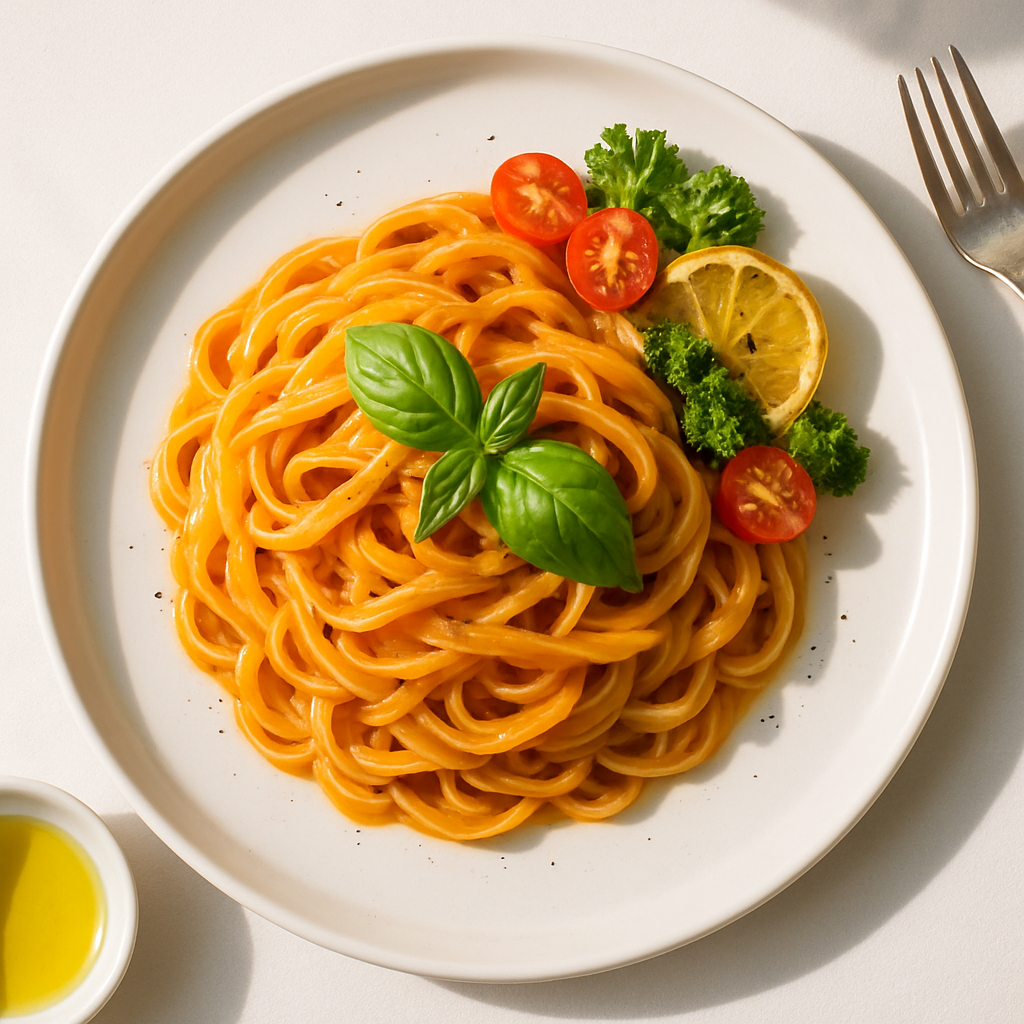

In [15]:
prompt = ("Gourmet pasta neatly plated with garnish and sides on a white ceramic plate, "
          "photographed from above on a restaurant table. Soft shadows and vibrant colors.")
cache_path = f".local_cache/{hash(prompt)}.png"

if not os.path.exists(cache_path):
    response = client.images.generate(
        model="gpt-image-1",
        prompt=prompt,
        size="1024x1024"
    )
    
    with open(cache_path, "wb") as f:
        f.write(base64.b64decode(response.data[0].b64_json))
    print(f"Generated and cached: {cache_path}")

else:
    print(f"Loading from cache: {cache_path}")

display(Image(filename=cache_path))

In [19]:
def  generate_food_delivery_review(sentiment: str = 'positive') -> str:
    """
    Generate a synthetic food delivery review witht the specified sentiment.

    Args:
        sentiment: An adjective such as 'positive' or 'negative'.

    Returns:
        Generate review text
    """
    prompt = "Write a very concise, realistic customer review for a recent food delivery."
    prompt += f" The review should reflect a {sentiment} experience."

    response = client.responses.create(
        model="gpt-5.4",
        reasoning={"effort": "low"},
        input=[{"role":"user", "content": prompt}]
    )
    return response.output_text

review = generate_food_delivery_review()
print(review)

Fast delivery, food arrived hot and fresh, and everything was exactly as ordered. Really happy with the service.


### Data Processing
In this example, we’ll work with a pre-generated synthetic dataset of customer feedback that includes short text snippets, images from customer reviews, and occasionally combined multimodal entries. You can also generate your own synthetic dataset using the examples provided above to tailor the data to your specific use case.

In [23]:
# Download the dataset
! mkdir -p .local_cache/images
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/df.csv -o .local_cache/df.csv


! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/1.png -o .local_cache/images/1.png
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/2.png -o .local_cache/images/2.png
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/3.png -o .local_cache/images/3.png
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/4.png -o .local_cache/images/4.png
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/5.png -o .local_cache/images/5.png
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/6.png -o .local_cache/images/6.png
! curl -L https://raw.githubusercontent.com/robtinn/image_understanding_rag_dataset/main/data/images/7.png -o .local_cache/images/7.png

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1926  100  1926    0     0  63757      0 --:--:-- --:--:-- --:--:-- 64200
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1979k  100 1979k    0     0  24.6M      0 --:--:-- --:--:-- --:--:-- 24.7M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1841k  100 1841k    0     0  10.9M      0 --:--:-- --:--:-- --:--:-- 11.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1817k  100 1817k    0     0  21.8M      0 --:--:-- --:--:-- --:--:-- 21.9M
  % Total    % Received % Xferd  Average Speed   Tim

In [27]:
def encode_image(image_path: str) -> str:
    """Encode image file to base64 string."""
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

def analyze_image_sentiment(image_path: str) -> str:
    """Analyze food delivery image and return sentiment analysis."""
    base64_image = encode_image(image_path)
    response = client.responses.create(
        model="gpt-5.4",
        reasoning= {"effort": "low"},
        input=[{
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": "Analyze this food delivery image. Respond with a brief description and sentiment (positive/negative) in one line."
                },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{base64_image}",
                },
            ],
        }],
    )
    return response.output_text.strip()

In [28]:
df = pd.read_csv(".local_cache/df.csv")
cache_dir = Path(".local_cache")

for idx, row in df[~df['image_path'].isna()].iterrows():
    image_path = cache_dir / 'images' /row['image_path']
    sentiment = analyze_image_sentiment(str(image_path))
    df.at[idx, 'full_sentiment'] = f"{row['text']} {sentiment}" if pd.notna(row['text']) else sentiment
    print(f"Processed {row['image_path']}")

df['full_sentiment'] = df['full_sentiment'].fillna(df['text'])

output_path = cache_dir / "df_full_sentiment.csv"
df.to_csv(output_path, index=False)
print(f"\nSaved results to {output_path}")

Processed 3.png
Processed 7.png
Processed 2.png
Processed 6.png
Processed 5.png
Processed 1.png
Processed 4.png

Saved results to .local_cache/df_full_sentiment.csv


In [29]:
pd.set_option('display.max_colwidth', 100)
display(df.head())

,id,month,text,image_path,label,full_sentiment
0,1,june,"Absolutely delicious! The sushi was fresh, beautifully packed, and arrived right on time. Will d...",NaN,positive,"Absolutely delicious! The sushi was fresh, beautifully packed, and arrived right on time. Will d..."
1,2,july,Half my order was missing and the burger looked thrown together. Not worth the money.,NaN,negative,Half my order was missing and the burger looked thrown together. Not worth the money.
2,3,july,Packaging was leaking sauce everywhere. Presentation was a mess. Tasted like leftovers.,NaN,negative,Packaging was leaking sauce everywhere. Presentation was a mess. Tasted like leftovers.
3,4,july,"Burger was hot, fries were still crispy, and the milkshake wasn’t melted at all. Fantastic deliv...",3.png,positive,"Burger was hot, fries were still crispy, and the milkshake wasn’t melted at all. Fantastic deliv..."
4,5,june,Received the wrong items. I ordered vegetarian and got meat. Totally unacceptable.,NaN,negative,Received the wrong items. I ordered vegetarian and got meat. Totally unacceptable.


### Populating Vector Store
This example uses OpenAI's built-in vector store and file search capabilities to build a RAG system that can analyse customer experiences from their feedback, which can be both visual and text-based. We create two vector stores for comparisons, one with image understanding and one without.